In [75]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/nikiw/nhert_zeitreihe_menden/projekt2/fuel_prices_Germany (1).csv')
print(df.head())
print(df.shape)

         date  country  region income_level subsidy_level  petrol_usd_liter  \
0  2020-01-06  Germany  Europe         High           Low             2.600   
1  2020-01-13  Germany  Europe         High           Low             2.581   
2  2020-01-20  Germany  Europe         High           Low             2.653   
3  2020-01-27  Germany  Europe         High           Low             2.678   
4  2020-02-03  Germany  Europe         High           Low             2.676   

   diesel_usd_liter  lpg_usd_liter  brent_crude_usd  tax_percentage  
0             2.476          1.955            65.75            53.2  
1             2.433          1.929            65.54            63.5  
2             2.495          1.980            66.51            57.6  
3             2.578          1.989            68.79            28.0  
4             2.571          1.986            68.44            59.5  
(327, 10)


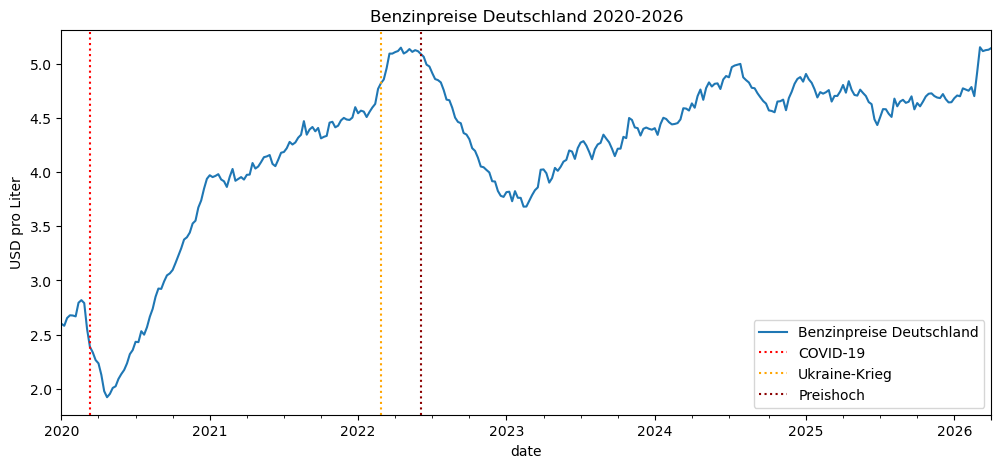

In [76]:
# Schritt 1 — Datenvorbereitung
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df = df.sort_index()

# Ereignisse auf dem Plot markieren
plt.figure(figsize=(12,5))
y.plot(label='Benzinpreise Deutschland')
plt.axvline(pd.Timestamp('2020-03-16'), color='red', 
            linestyle=':', label='COVID-19')
plt.axvline(pd.Timestamp('2022-02-24'), color='orange', 
            linestyle=':', label='Ukraine-Krieg')
plt.axvline(pd.Timestamp('2022-06-01'), color='darkred', 
            linestyle=':', label='Preishoch')
plt.title('Benzinpreise Deutschland 2020-2026')
plt.ylabel('USD pro Liter')
plt.legend()
plt.show()

In [77]:
# Schritt 1 — ADF-Test (Stationaritätstest)
from statsmodels.tsa.stattools import adfuller

y = df['petrol_usd_liter']

result = adfuller(y)
print(f'ADF-Statistik: {result[0]:.4f}')
print(f'p-Wert: {result[1]:.4f}')

if result[1] < 0.05:
    print('→ Zeitreihe ist STATIONÄR')
else:
    print('→ Zeitreihe ist NICHT stationär → muss differenziert werden')

ADF-Statistik: -2.4241
p-Wert: 0.1350
→ Zeitreihe ist NICHT stationär → muss differenziert werden


p-Wert nach Differenzierung: 0.0000
→ Jetzt stationär (d=1)


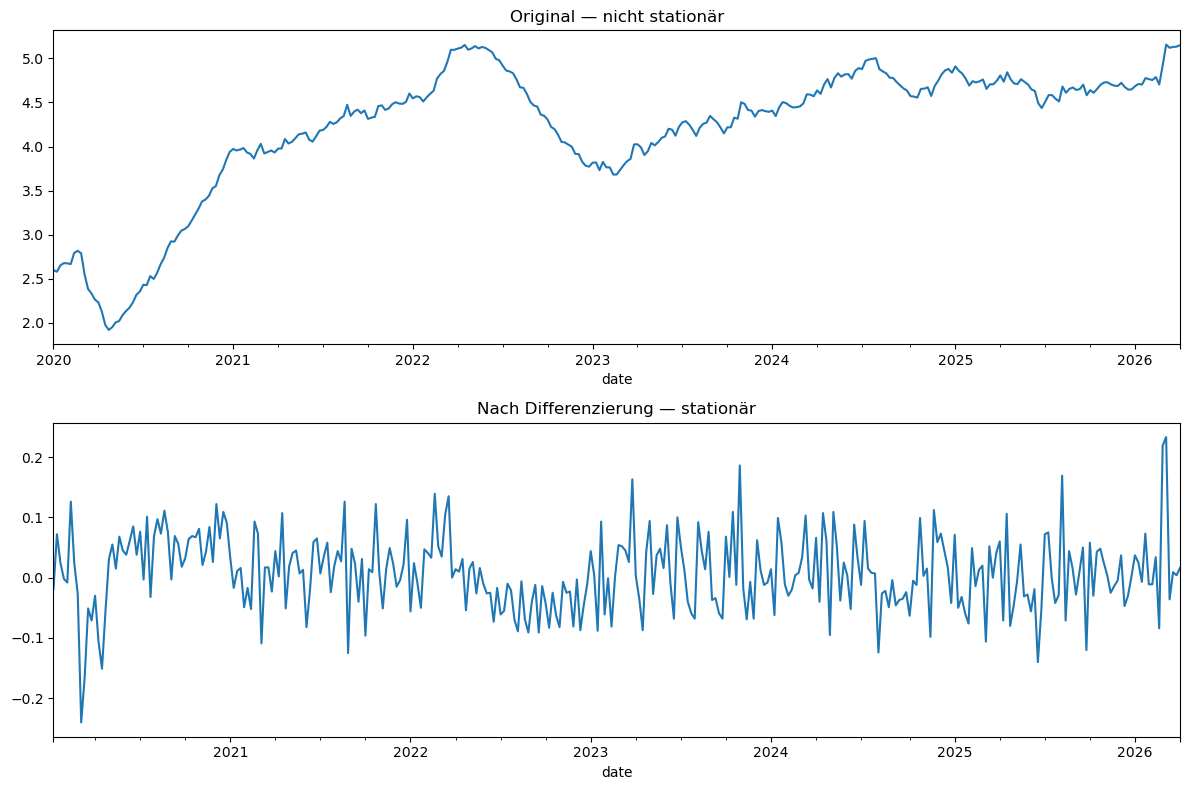

In [78]:
# Schritt 2 — Differenzierung
y_diff = y.diff().dropna()

# ADF-Test nach Differenzierung
result2 = adfuller(y_diff)
print(f'p-Wert nach Differenzierung: {result2[1]:.4f}')

if result2[1] < 0.05:
    print('→ Jetzt stationär (d=1)')
else:
    print('→ Immer noch nicht stationär')

# Vergleich Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
y.plot(ax=axes[0], title='Original — nicht stationär')
y_diff.plot(ax=axes[1], title='Nach Differenzierung — stationär')
plt.tight_layout()
plt.show()

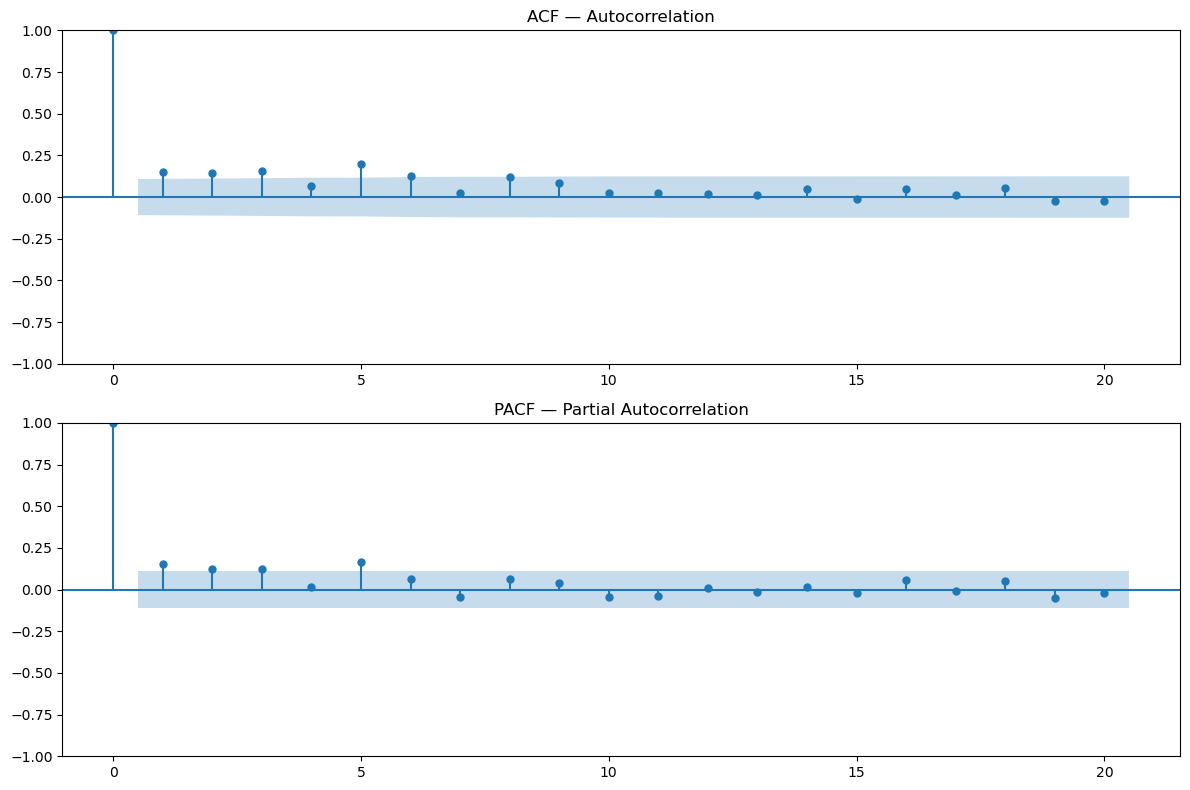

In [79]:
# Schritt 3 — ACF und PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y_diff, lags=20, ax=axes[0], title='ACF — Autocorrelation')
plot_pacf(y_diff, lags=20, ax=axes[1], title='PACF — Partial Autocorrelation')

plt.tight_layout()
plt.show()

In [80]:
# Schritt 4 — Modellauswahl ARIMA
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Verschiedene Modelle testen
modelle = [(1,1,1), (1,1,2), (2,1,1), (2,1,2)]

ergebnisse = []
for p,d,q in modelle:
    model = ARIMA(y, order=(p,d,q))
    result = model.fit()
    ergebnisse.append((p,d,q, round(result.aic, 2), round(result.bic, 2)))
    print(f'ARIMA({p},{d},{q}) — AIC: {result.aic:.2f}, BIC: {result.bic:.2f}')

# Bestes Modell (niedrigstes AIC)
bestes = min(ergebnisse, key=lambda x: x[3])
print(f'\nBestes Modell: ARIMA({bestes[0]},{bestes[1]},{bestes[2]}) mit AIC={bestes[3]}')

ARIMA(1,1,1) — AIC: -893.04, BIC: -881.68
ARIMA(1,1,2) — AIC: -891.21, BIC: -876.06
ARIMA(2,1,1) — AIC: -891.20, BIC: -876.05
ARIMA(2,1,2) — AIC: -889.29, BIC: -870.36

Bestes Modell: ARIMA(1,1,1) mit AIC=-893.04


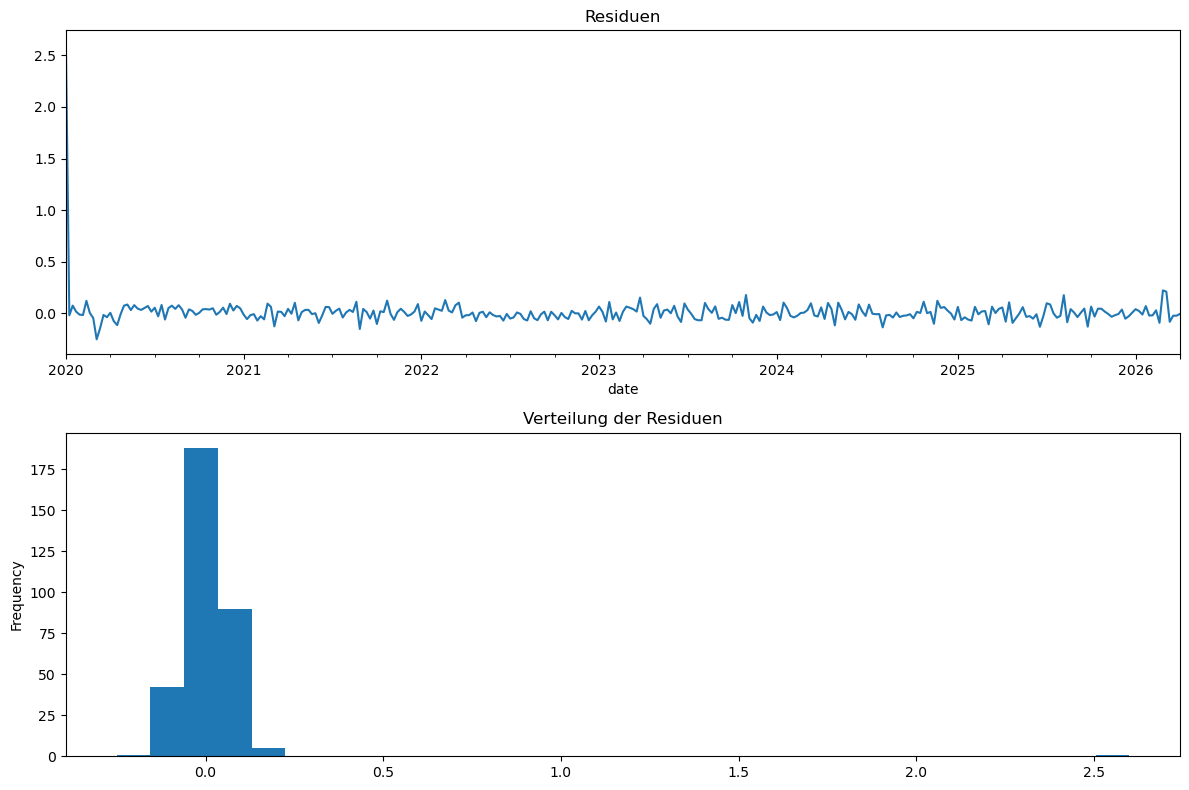

     lb_stat  lb_pvalue
1   0.036139   0.849229
2   0.199891   0.904887
3   0.217303   0.974749
4   0.307340   0.989335
5   0.340225   0.996817
6   0.985831   0.986144
7   1.023203   0.994446
8   1.044562   0.997951
9   3.206734   0.955531
10  4.224808   0.936636
→ Modell gut spezifiziert (keine Autokorrelation in Residuen)


In [81]:
# Schritt 5 — Residuenanalyse
from statsmodels.stats.diagnostic import acorr_ljungbox

# Bestes Modell fitten
model = ARIMA(y, order=(1,1,1))
result = model.fit()

# Residuen plotten
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
result.resid.plot(ax=axes[0], title='Residuen')
result.resid.plot(kind='hist', ax=axes[1], title='Verteilung der Residuen', bins=30)
plt.tight_layout()
plt.show()

# Ljung-Box Test
lb = acorr_ljungbox(result.resid, lags=10, return_df=True)
print(lb)
if lb['lb_pvalue'].min() > 0.05:
    print('→ Modell gut spezifiziert (keine Autokorrelation in Residuen)')
else:
    print('→ Noch Autokorrelation in Residuen vorhanden')

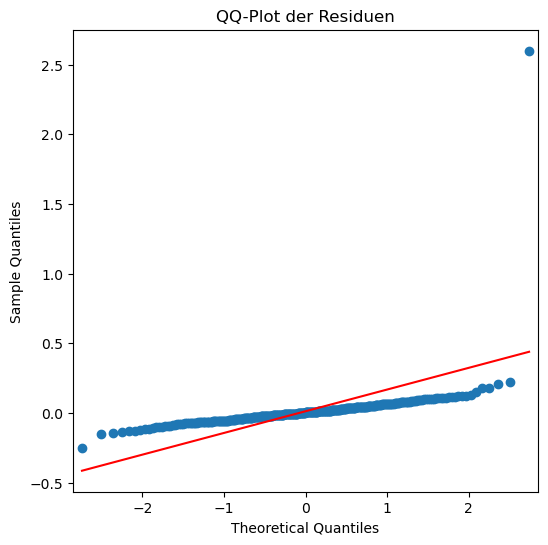

In [82]:
# QQ-Plot — Normalverteilung der Residuen
import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(result.resid, line='s', ax=ax)
ax.set_title('QQ-Plot der Residuen')
plt.show()

In [83]:
# Schritt 6 — t-Statistiken der Koeffizienten
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:       petrol_usd_liter   No. Observations:                  327
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 449.520
Date:                Sat, 16 May 2026   AIC                           -893.040
Time:                        01:35:29   BIC                           -881.680
Sample:                    01-06-2020   HQIC                          -888.507
                         - 04-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9047      0.065     13.918      0.000       0.777       1.032
ma.L1         -0.7849      0.087     -8.999      0.000      -0.956      -0.614
sigma2         0.0037      0.000     16.109      0.0

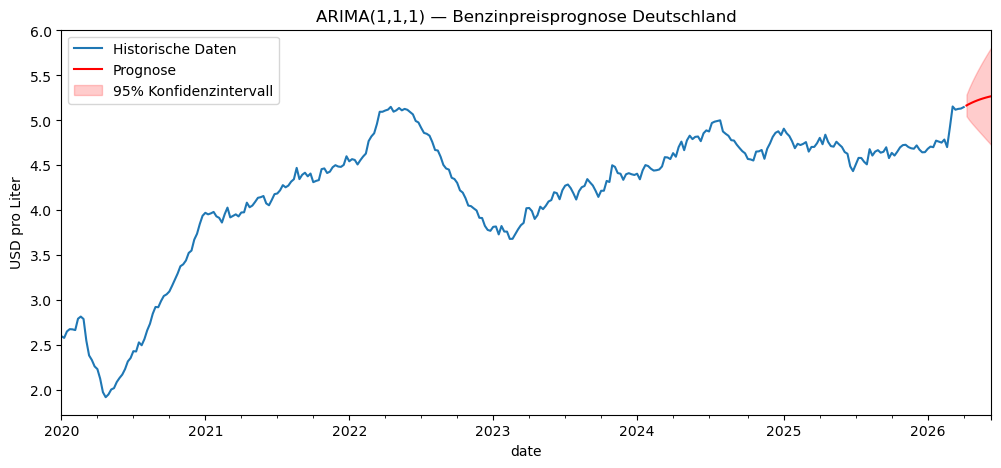


Prognose für die nächsten 10 Wochen:
2026-04-13    5.1663
2026-04-20    5.1828
2026-04-27    5.1978
2026-05-04    5.2113
2026-05-11    5.2236
2026-05-18    5.2346
2026-05-25    5.2447
2026-06-01    5.2537
2026-06-08    5.2619
2026-06-15    5.2694
Freq: W-MON, Name: predicted_mean, dtype: float64


In [84]:
# Schritt 7 — Prognose für 10 Perioden
forecast = result.get_forecast(steps=10)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot
plt.figure(figsize=(12,5))
y.plot(label='Historische Daten')
forecast_mean.plot(label='Prognose', color='red')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='red', alpha=0.2, label='95% Konfidenzintervall')
plt.title('ARIMA(1,1,1) — Benzinpreisprognose Deutschland')
plt.ylabel('USD pro Liter')
plt.legend()
plt.show()

print('\nPrognose für die nächsten 10 Wochen:')
print(forecast_mean.round(4))

In [85]:
# Prognose-Tabelle
forecast_df = pd.DataFrame({
    'Datum': forecast_mean.index.strftime('%d.%m.%Y'),
    'Prognose (USD/L)': forecast_mean.round(4).values,
    'KI unten': forecast_ci.iloc[:,0].round(4).values,
    'KI oben': forecast_ci.iloc[:,1].round(4).values
})

print("=" * 55)
print("  10-Wochen-Prognose Benzinpreise Deutschland")
print("=" * 55)
print(forecast_df.to_string(index=False))
print("=" * 55)
print(f"  Modell: ARIMA(1,1,1)")
print(f"  Konfidenzintervall: 95%")
print("=" * 55)

  10-Wochen-Prognose Benzinpreise Deutschland
     Datum  Prognose (USD/L)  KI unten  KI oben
13.04.2026            5.1663    5.0469   5.2857
20.04.2026            5.1828    5.0036   5.3621
27.04.2026            5.1978    4.9662   5.4294
04.05.2026            5.2113    4.9307   5.4919
11.05.2026            5.2236    4.8960   5.5511
18.05.2026            5.2346    4.8616   5.6077
25.05.2026            5.2447    4.8273   5.6620
01.06.2026            5.2537    4.7930   5.7144
08.06.2026            5.2619    4.7588   5.7651
15.06.2026            5.2694    4.7247   5.8140
  Modell: ARIMA(1,1,1)
  Konfidenzintervall: 95%
